<a href="https://colab.research.google.com/github/amy165/Insurance-Risk-Pricing-Analysis-End-to-End-Project/blob/main/notebooks/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
full_df=pd.read_csv('cleaned_vehicle_insurance_new.csv')

In [3]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800996 entries, 0 to 800995
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   SEX                800996 non-null  int64  
 1   INSR_BEGIN         800996 non-null  object 
 2   INSR_END           800996 non-null  object 
 3   INSR_TYPE          800996 non-null  int64  
 4   INSURED_VALUE      800996 non-null  float64
 5   PREMIUM            800996 non-null  float64
 6   OBJECT_ID          800996 non-null  int64  
 7   PROD_YEAR          800996 non-null  float64
 8   SEATS_NUM          800996 non-null  float64
 9   CARRYING_CAPACITY  800996 non-null  float64
 10  TYPE_VEHICLE       800996 non-null  object 
 11  CCM_TON            800996 non-null  float64
 12  MAKE               800996 non-null  object 
 13  USAGE              800996 non-null  object 
 14  CLAIM_PAID         800996 non-null  float64
 15  insured_redflag    800996 non-null  int64  
 16  PR

In [4]:
full_df['INSR_BEGIN'] = pd.to_datetime(full_df['INSR_BEGIN'])
full_df['INSR_END'] = pd.to_datetime(full_df['INSR_END'])

In [5]:
full_df.isnull().sum()

,0
SEX,0
INSR_BEGIN,0
INSR_END,0
INSR_TYPE,0
INSURED_VALUE,0
PREMIUM,0
OBJECT_ID,0
PROD_YEAR,0
SEATS_NUM,0
CARRYING_CAPACITY,0


In [6]:
full_df.head()

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
0,0,2013-08-08,2014-08-07,1202,519755.22,7209.140,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2013,364,0,6.0
1,0,2012-08-08,2013-08-07,1202,519755.22,7203.890,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2012,364,0,5.0
2,0,2011-08-08,2012-08-07,1202,519755.22,7045.804,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2011,365,0,4.0
3,0,2011-07-08,2011-08-07,1202,519755.22,287.250,5000029885,2007.0,4.0,6.0,...,0.00,0,0,0,0,0,2011,30,0,4.0
4,0,2013-08-08,2014-08-07,1202,285451.24,4286.900,5000029901,2010.0,4.0,7.0,...,19894.43,0,0,0,0,0,2013,364,1,3.0


In [7]:
model_df=full_df.copy()

In [8]:
model_df.describe()

,SEX,INSR_BEGIN,INSR_END,INSR_TYPE,INSURED_VALUE,PREMIUM,OBJECT_ID,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,...,CLAIM_PAID,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age
count,800996.000000,800996,800996,800996.000000,8.009960e+05,8.009960e+05,8.009960e+05,800996.000000,800996.000000,800996.000000,...,8.009960e+05,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000
mean,0.567291,2015-03-06 05:56:09.383117824,2016-02-20 16:53:43.422838528,1201.741577,7.141157e+05,7.411078e+03,5.000453e+09,2004.528482,6.249453,391.662203,...,1.924206e+04,0.428154,0.000061,0.529795,0.110376,0.074550,2014.676760,351.456644,0.075000,10.151820
min,0.000000,2011-07-01 00:00:00,2011-07-13 00:00:00,1201.000000,1.000000e+00,0.000000e+00,5.000018e+09,1950.000000,1.000000,1.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2011.000000,1.000000,0.000000,0.000000
25%,0.000000,2013-07-08 00:00:00,2014-07-02 00:00:00,1201.000000,2.150000e+05,7.573922e+02,5.000160e+09,2000.000000,2.000000,4.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2013.000000,364.000000,0.000000,2.000000
50%,0.000000,2015-06-18 00:00:00,2016-06-02 00:00:00,1202.000000,5.000000e+05,3.381345e+03,5.000380e+09,2008.000000,4.000000,7.000000,...,0.000000e+00,0.000000,0.000000,1.000000,0.000000,0.000000,2015.000000,364.000000,0.000000,7.000000
75%,1.000000,2016-12-21 00:00:00,2017-12-15 00:00:00,1202.000000,9.400000e+05,9.649250e+03,5.000718e+09,2012.000000,4.000000,43.000000,...,0.000000e+00,1.000000,0.000000,1.000000,0.000000,0.000000,2016.000000,364.000000,0.000000,15.000000
max,2.000000,2018-06-30 00:00:00,2019-06-29 00:00:00,1204.000000,2.500000e+08,7.581230e+06,5.001351e+09,2018.000000,199.000000,1000000.000000,...,1.524458e+08,1.000000,1.000000,1.000000,1.000000,1.000000,2018.000000,523.000000,1.000000,68.000000
std,0.644479,NaN,NaN,0.439160,8.640663e+05,1.352969e+04,3.444586e+05,10.227622,13.366344,3366.238249,...,4.152232e+05,0.494812,0.007821,0.499112,0.313358,0.262664,2.094161,58.758793,0.263392,9.852646


In [9]:
model_df['MAKE'].value_counts()

,count
MAKE,
TOYOTA,272451
ISUZU,75602
BAJAJI,67267
NISSAN,37168
MITSUBISHI,22086
...,...
LOADER POERR PLUS,1
A,1
BAYBEN FIRE FIGHTER,1


In [10]:
top_makes = model_df['MAKE'].value_counts().nlargest(20).index

model_df['MAKE_grouped'] = model_df['MAKE'].where(
    model_df['MAKE'].isin(top_makes),
    'Other'
)

In [11]:
model_df['vehicle_age'].value_counts()

,count
vehicle_age,
1.0,82388
2.0,71809
3.0,61315
4.0,49988
0.0,48604
...,...
67.0,9
63.0,7
66.0,5


In [12]:
model_df['vehicle_age_group'] = pd.cut(
    model_df['vehicle_age'],
    bins=[0, 3, 10, 20, 100],
    labels=['new', 'young', 'mid', 'old'],
    include_lowest=True
)
model_df['vehicle_age_group'].value_counts()

,count
vehicle_age_group,
new,264116
young,243422
mid,159764
old,133694


In [13]:
model_df['policy_duration_group'] = pd.cut(
    model_df['policy_duration'],
    bins=[0, 60, 200, 370, 600],
    labels=['very_short', 'medium', 'annual', 'long'],
    include_lowest=True
)
model_df['policy_duration_group'].value_counts()

,count
policy_duration_group,
annual,765679
very_short,17826
medium,17459
long,32


In [14]:
model_df['insured_value_group'] = pd.cut(
    model_df['INSURED_VALUE'],
    bins=[0, 100000, 500000, 1000000, 250000000],
    labels=['low', 'medium', 'high', 'very_high'],
    include_lowest=True
)
model_df['insured_value_group'].value_counts()

,count
insured_value_group,
medium,271340
high,196242
very_high,182363
low,151051


In [15]:
model_df = model_df.drop(columns=[
    'PREMIUM',
    'CLAIM_PAID',
    'loss_ratio',
    'OBJECT_ID',
    'INSR_BEGIN',
    'INSR_END'
], errors='ignore')

In [16]:
model_df.columns

Index(['SEX', 'INSR_TYPE', 'INSURED_VALUE', 'PROD_YEAR', 'SEATS_NUM',
       'CARRYING_CAPACITY', 'TYPE_VEHICLE', 'CCM_TON', 'MAKE', 'USAGE',
       'insured_redflag', 'PREMIUM_redflag', 'CARRYING_redflag',
       'CCM_TON_redflag', 'SEATS_NUM_redflag', 'begin_year', 'policy_duration',
       'has_claim', 'vehicle_age', 'MAKE_grouped', 'vehicle_age_group',
       'policy_duration_group', 'insured_value_group'],
      dtype='object')

In [17]:
num_features = [
    'INSURED_VALUE',
    'PROD_YEAR',
    'SEATS_NUM',
    'CARRYING_CAPACITY',
    'CCM_TON',
    'begin_year',
    'policy_duration',
    'vehicle_age',
    'insured_redflag',
    'PREMIUM_redflag',
    'CARRYING_redflag',
    'CCM_TON_redflag',
    'SEATS_NUM_redflag'
]

In [18]:
cat_features = [
    'SEX',
    'INSR_TYPE',
    'TYPE_VEHICLE',
    'USAGE',
    'MAKE_grouped',
    'vehicle_age_group',
    'policy_duration_group',
    'insured_value_group'
]

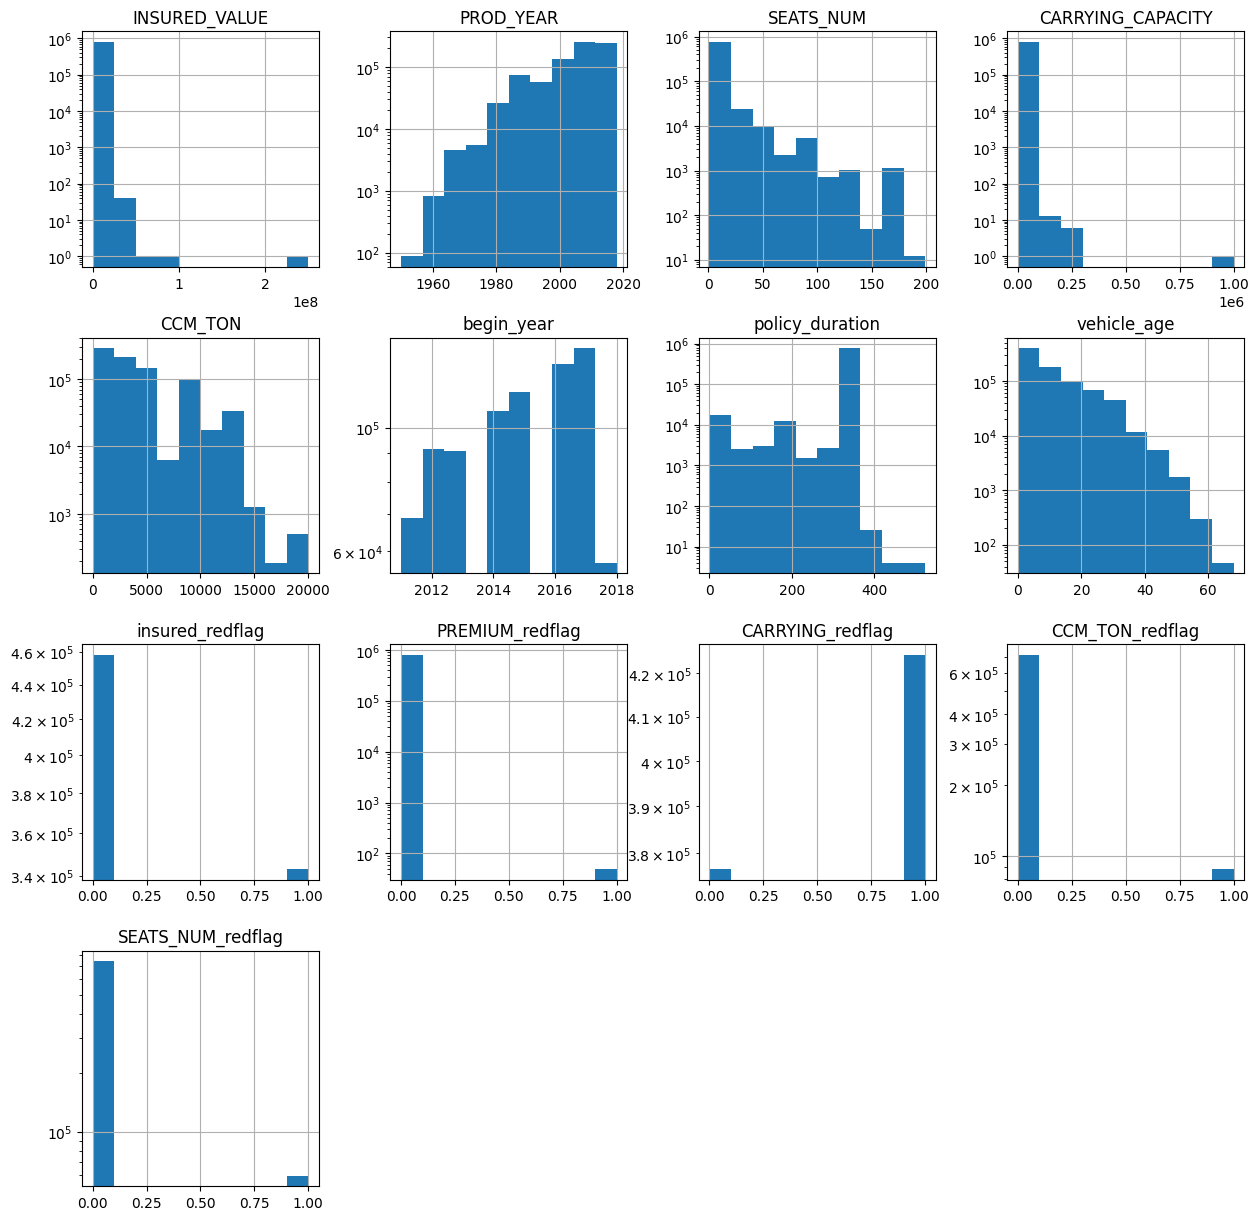

In [19]:
model_df[num_features].hist(figsize=(15,15), log=True)
plt.show()

In [20]:
model_df[num_features].describe()

,INSURED_VALUE,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,CCM_TON,begin_year,policy_duration,vehicle_age,insured_redflag,PREMIUM_redflag,CARRYING_redflag,CCM_TON_redflag,SEATS_NUM_redflag
count,8.009960e+05,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000,800996.000000
mean,7.141157e+05,2004.528482,6.249453,391.662203,3858.917938,2014.676760,351.456644,10.151820,0.428154,0.000061,0.529795,0.110376,0.074550
std,8.640663e+05,10.227622,13.366344,3366.238249,3578.805763,2.094161,58.758793,9.852646,0.494812,0.007821,0.499112,0.313358,0.262664
min,1.000000e+00,1950.000000,1.000000,1.000000,0.500000,2011.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.150000e+05,2000.000000,2.000000,4.000000,1296.000000,2013.000000,364.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.000000e+05,2008.000000,4.000000,7.000000,2779.000000,2015.000000,364.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,9.400000e+05,2012.000000,4.000000,43.000000,4334.000000,2016.000000,364.000000,15.000000,1.000000,0.000000,1.000000,0.000000,0.000000
max,2.500000e+08,2018.000000,199.000000,1000000.000000,20000.000000,2018.000000,523.000000,68.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
model_df[model_df['CARRYING_CAPACITY']>200000]

,SEX,INSR_TYPE,INSURED_VALUE,PROD_YEAR,SEATS_NUM,CARRYING_CAPACITY,TYPE_VEHICLE,CCM_TON,MAKE,USAGE,...,CCM_TON_redflag,SEATS_NUM_redflag,begin_year,policy_duration,has_claim,vehicle_age,MAKE_grouped,vehicle_age_group,policy_duration_group,insured_value_group
34256,0,1202,679305.0,2002.0,4.0,1000000.0,Pick-up,2892.0,FORD,Own Goods,...,0,1,2011,365,0,9.0,FORD,young,annual,high
224799,1,1202,250000.0,1996.0,1.0,224000.0,Trailers and semitrailers,9720.0,MARU,General Cartage,...,1,1,2013,364,0,17.0,Other,mid,annual,medium
224800,1,1202,300000.0,1996.0,1.0,224000.0,Trailers and semitrailers,9720.0,MARU,General Cartage,...,1,1,2012,364,0,16.0,Other,mid,annual,medium
460490,1,1202,250000.0,1996.0,1.0,224000.0,Trailers and semitrailers,9720.0,MARU,General Cartage,...,1,1,2017,364,0,21.0,Other,old,annual,medium
460491,1,1202,250000.0,1996.0,1.0,224000.0,Trailers and semitrailers,9720.0,MARU,General Cartage,...,1,1,2016,364,0,20.0,Other,mid,annual,medium
460492,1,1202,250000.0,1996.0,1.0,224000.0,Trailers and semitrailers,9720.0,MARU,General Cartage,...,1,1,2015,365,0,19.0,Other,mid,annual,medium
460493,1,1202,250000.0,1996.0,1.0,224000.0,Trailers and semitrailers,9720.0,MARU,General Cartage,...,1,1,2014,364,0,18.0,Other,mid,annual,medium


In [22]:
model_df['INSURED_VALUE_log'] = np.log1p(model_df['INSURED_VALUE'])
model_df['CARRYING_CAPACITY_log'] = np.log1p(model_df['CARRYING_CAPACITY'])

In [23]:
num_features_logistic = [
    'INSURED_VALUE_log',
    'CARRYING_CAPACITY_log',
    'SEATS_NUM',
    'CCM_TON',
    'PROD_YEAR',
    'begin_year',
    'policy_duration',
    'vehicle_age',
    'insured_redflag',
    'PREMIUM_redflag',
    'CARRYING_redflag',
    'CCM_TON_redflag',
    'SEATS_NUM_redflag'
]

In [24]:
num_features_tree = [
    'INSURED_VALUE',
    'CARRYING_CAPACITY',
    'SEATS_NUM',
    'CCM_TON',
    'PROD_YEAR',
    'begin_year',
    'policy_duration',
    'vehicle_age',
    'insured_redflag',
    'PREMIUM_redflag',
    'CARRYING_redflag',
    'CCM_TON_redflag',
    'SEATS_NUM_redflag'
]

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [26]:
X_log = model_df[num_features_logistic + cat_features]
y = model_df['has_claim']

In [27]:
X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [28]:
X_log_train = pd.get_dummies(X_log_train, drop_first=True)
X_log_test = pd.get_dummies(X_log_test, drop_first=True)

#asegurar X_train y X_test tengan columnas en mismo orden
X_log_test = X_log_test.reindex(columns=X_log_train.columns, fill_value=0)

In [29]:
model_LR=LogisticRegression(max_iter=1000)
model_LR.fit(X_log_train, y_log_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [30]:
y_pred_LR = model_LR.predict(X_log_test)
y_prob_LR = model_LR.predict_proba(X_log_test)[:,1]

print(classification_report(y_log_test, y_pred_LR))
print("ROC-AUC:", roc_auc_score(y_log_test, y_prob_LR))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96    148185
           1       0.41      0.00      0.01     12015

    accuracy                           0.92    160200
   macro avg       0.67      0.50      0.48    160200
weighted avg       0.89      0.92      0.89    160200

ROC-AUC: 0.760205567123605


using weight **balanced**

In [31]:
model_LR_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_LR_balanced.fit(X_log_train, y_log_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

In [32]:
y_pred_LR_balanced = model_LR_balanced.predict(X_log_test)
y_prob_LR_balanced = model_LR_balanced.predict_proba(X_log_test)[:,1]

print(classification_report(y_log_test, y_pred_LR_balanced))
print("ROC-AUC:", roc_auc_score(y_log_test, y_prob_LR_balanced))

              precision    recall  f1-score   support

           0       0.98      0.59      0.74    148185
           1       0.14      0.84      0.24     12015

    accuracy                           0.61    160200
   macro avg       0.56      0.72      0.49    160200
weighted avg       0.92      0.61      0.70    160200

ROC-AUC: 0.7606726509365065


In [33]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (y_prob_LR_balanced > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_log_test, y_pred_t))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.29      0.45    148185
           1       0.10      0.97      0.18     12015

    accuracy                           0.34    160200
   macro avg       0.55      0.63      0.32    160200
weighted avg       0.92      0.34      0.43    160200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.47      0.64    148185
           1       0.12      0.92      0.22     12015

    accuracy                           0.50    160200
   macro avg       0.56      0.70      0.43    160200
weighted avg       0.92      0.50      0.61    160200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.53      0.69    148185
           1       0.13      0.89      0.23     12015

    accuracy                           0.56    160200
   macro avg       0.56      0.71      0.46    160200
weighted avg       0.92   

RandomForest

In [34]:
X_tree = model_df[num_features_tree + cat_features]
y = model_df['has_claim']

In [35]:
X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
X_tree_train = pd.get_dummies(X_tree_train, drop_first=True)
X_tree_test = pd.get_dummies(X_tree_test, drop_first=True)

#asegurar X_train y X_test tengan columnas en mismo orden
X_tree_test = X_tree_test.reindex(columns=X_tree_train.columns, fill_value=0)

In [37]:
model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

model_rf.fit(X_tree_train, y_tree_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [38]:
y_prob_rf = model_rf.predict_proba(X_tree_test)[:,1]
y_pred_rf = model_rf.predict(X_tree_test)

print(classification_report(y_tree_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_tree_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92    148185
           1       0.20      0.29      0.23     12015

    accuracy                           0.86    160200
   macro avg       0.57      0.60      0.58    160200
weighted avg       0.88      0.86      0.87    160200

ROC-AUC: 0.7099485643395644


randomforest n_estimators=200 max_depth=10

In [39]:
model_rf_md10 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

model_rf_md10.fit(X_tree_train, y_tree_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [40]:
y_prob_rf_md10 = model_rf_md10.predict_proba(X_tree_test)[:,1]
y_pred_rf_md10 = model_rf_md10.predict(X_tree_test)

print(classification_report(y_tree_test, y_pred_rf_md10))
print("ROC-AUC:", roc_auc_score(y_tree_test, y_prob_rf_md10))

              precision    recall  f1-score   support

           0       0.98      0.60      0.75    148185
           1       0.15      0.84      0.25     12015

    accuracy                           0.62    160200
   macro avg       0.56      0.72      0.50    160200
weighted avg       0.92      0.62      0.71    160200

ROC-AUC: 0.7846302465407797


In [41]:
importances_rf = pd.Series(model_rf_md10.feature_importances_, index=X_tree_train.columns)
importances_rf.sort_values(ascending=False).head(15)

,0
insured_redflag,0.266816
INSURED_VALUE,0.102921
CARRYING_CAPACITY,0.091586
TYPE_VEHICLE_Motor-cycle,0.076973
CCM_TON,0.072266
SEATS_NUM,0.051807
PROD_YEAR,0.034595
policy_duration,0.031630
vehicle_age,0.030797
MAKE_grouped_BAJAJI,0.017138


XGBoost

In [42]:
scale_pos_weight = (y_tree_train == 0).sum() / (y_tree_train == 1).sum()

model_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

model_xgb.fit(X_tree_train, y_tree_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:52:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [43]:
y_pred_xgb = model_xgb.predict(X_tree_test)
y_prob_xgb = model_xgb.predict_proba(X_tree_test)[:, 1]

print(classification_report(y_tree_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_tree_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.98      0.61      0.75    148185
           1       0.15      0.84      0.25     12015

    accuracy                           0.63    160200
   macro avg       0.56      0.73      0.50    160200
weighted avg       0.92      0.63      0.71    160200

ROC-AUC: 0.7900498798676638


In [44]:
for t in [0.2, 0.3, 0.4, 0.5]:
    y_pred_xgb_t = (y_prob_xgb > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_tree_test, y_pred_xgb_t))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.39      0.56    148185
           1       0.11      0.96      0.20     12015

    accuracy                           0.44    160200
   macro avg       0.55      0.68      0.38    160200
weighted avg       0.93      0.44      0.54    160200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.46      0.63    148185
           1       0.12      0.94      0.22     12015

    accuracy                           0.49    160200
   macro avg       0.56      0.70      0.42    160200
weighted avg       0.93      0.49      0.59    160200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.99      0.53      0.69    148185
           1       0.14      0.91      0.24     12015

    accuracy                           0.56    160200
   macro avg       0.56      0.72      0.46    160200
weighted avg       0.92   

In [45]:
importances_xgb = pd.Series(model_xgb.feature_importances_, index=X_tree_train.columns)
importances_xgb.sort_values(ascending=False).head(15)

,0
insured_redflag,0.437829
TYPE_VEHICLE_Motor-cycle,0.118415
SEATS_NUM,0.042025
SEATS_NUM_redflag,0.036150
policy_duration,0.028663
TYPE_VEHICLE_Trailers and semitrailers,0.023298
USAGE_General Cartage,0.020287
CARRYING_CAPACITY,0.019362
USAGE_Own Goods,0.016312
TYPE_VEHICLE_Bus,0.016142


In [46]:
importances = pd.Series(model_xgb.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(15)

NameError: name 'X_train' is not defined